In [10452]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

import warnings
warnings.filterwarnings("ignore") #just to supress warnings

In [10453]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  #avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique'),
                  d=('d', 'first')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['d', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['d'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['d', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, agg




In [10454]:
#Read data (remove v = 0.05 because we chose not to include it)
data_ttb = pd.read_csv('results_300/ttb_LS.csv')
data_ttb = data_ttb[data_ttb['seed'] < 933]

data_xgboost = pd.read_csv('results_300/xgb.csv')
#data_xgboost = data_xgboost[data_xgboost['seed'] < 932]

data_xgboost_warmstart = pd.read_csv('results_300/xgb_warmstart.csv')
#data_xgboost_warmstart = data_xgboost_warmstart[data_xgboost_warmstart['seed'] < 932]

data_xgboost_pooled = pd.read_csv('results_300/xgb_naive.csv')
#data_xgboost_pooled = data_xgboost_pooled[data_xgboost_pooled['seed'] < 932]

#data_two_trada = pd.read_csv('results_200/two_trada.csv')


# Here we make final vizes!

<Axes: xlabel='d', ylabel='rmse'>

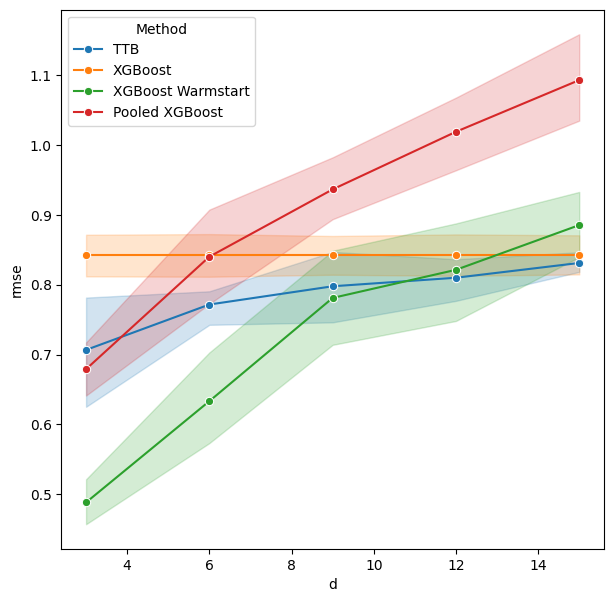

In [10455]:

plt.figure(figsize = (7,7))

import matplotlib as mpl

best_ttb, best_ttb_params = topk_per_d_per_method(
    data_ttb,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=3
)
best_ttb['Method'] = 'TTB'

best_xgboost, best_xgboost_params = topk_per_d_per_method(
    data_xgboost,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost['Method'] = 'XGBoost'

best_xgboost_warmstart, best_xgboost_warmstart_params = topk_per_d_per_method(
    data_xgboost_warmstart,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost_warmstart['Method'] = 'XGBoost Warmstart'

best_xgboost_pooled, best_xgboost_pooled_params = topk_per_d_per_method(
    data_xgboost_pooled,
    ['d', 'v', 'target_tree_size'], k=10
)
best_xgboost_pooled['Method'] = 'Pooled XGBoost'

# best_trada, best_trada_params = topk_per_d_per_method(
#     data_two_trada,
#     ['d', 'lr', 'n_estimators', 'tree_size'], k=10
# )
# best_trada['Method'] = 'TrAdaBoost.R2'


# create new df for viz
df = pd.concat([best_ttb, best_xgboost])
df = pd.concat([df, best_xgboost_warmstart])
df = pd.concat([df, best_xgboost_pooled])
#df = pd.concat([df, best_trada])
sns.lineplot(data=df, x='d', y='rmse', hue='Method', marker = 'o')



In [10456]:
(1.24 + 1.21 + 1.26 + 1.33 + 1.39) / 5

1.286

In [10457]:
best_ttb_params

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,d,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
189,0.30,2,2,0.01,0.9,0.706642,3,3,62,930,LSTransferTreeBoost,1000,0.640633,0.497550,0.625280,0.503651
190,0.30,2,2,0.01,0.9,0.706642,3,3,422,931,LSTransferTreeBoost,1000,0.758757,0.608675,0.781502,0.622816
191,0.30,2,2,0.01,0.9,0.706642,3,3,782,932,LSTransferTreeBoost,1000,0.779725,0.604518,0.713145,0.559744
135,0.20,2,2,0.01,0.9,0.712185,3,3,44,930,LSTransferTreeBoost,1000,0.612278,0.483050,0.609976,0.486148
136,0.20,2,2,0.01,0.9,0.712185,3,3,404,931,LSTransferTreeBoost,1000,0.787123,0.630838,0.810979,0.638464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,0.05,1,1,0.00,0.5,1.064894,3,15,289,930,LSTransferTreeBoost,1000,1.131911,0.914643,1.121132,0.905721
865,0.05,1,1,0.00,0.5,1.064894,3,15,649,931,LSTransferTreeBoost,1000,1.007995,0.806748,1.029797,0.820908
866,0.05,1,1,0.00,0.5,1.064894,3,15,1009,932,LSTransferTreeBoost,1000,1.122486,0.876927,1.043753,0.823028
882,0.05,2,1,0.00,0.5,1.076592,2,15,295,930,LSTransferTreeBoost,1000,1.126084,0.906983,1.123386,0.907726


In [10458]:
best_xgboost_pooled_params

,v,target_tree_size,avg_rmse,n_seeds,d,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae
20,0.05,3.0,0.679124,10,3.0,2,930.0,0.761002,0.592671,0.794262,0.618880
21,0.05,3.0,0.679124,10,3.0,387,931.0,0.616798,0.485143,0.606221,0.481616
22,0.05,3.0,0.679124,10,3.0,772,932.0,0.731449,0.584348,0.697937,0.556029
23,0.05,3.0,0.679124,10,3.0,1157,933.0,0.673873,0.504912,0.719896,0.558752
24,0.05,3.0,0.679124,10,3.0,1542,934.0,0.637834,0.513222,0.607336,0.478908
...,...,...,...,...,...,...,...,...,...,...,...
3085,0.05,1.0,3.171501,10,15.0,2233,935.0,3.447463,2.792966,3.605908,2.909423
3086,0.05,1.0,3.171501,10,15.0,2618,936.0,5.667545,4.653387,5.406296,4.371100
3087,0.05,1.0,3.171501,10,15.0,3003,937.0,1.213207,0.948164,1.227919,0.956483
3088,0.05,1.0,3.171501,10,15.0,3388,938.0,3.146214,2.517611,3.309940,2.617415
